# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

## Import Statements

In [1]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
import statsmodels
from sklearn.linear_model import LinearRegression
import sqlite3

## Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [3]:
df_hh_income = pd.read_csv('data/csv_format/raw_data/Median_Household_Income_2015.csv', encoding="windows-1252")
df_poverty_pct = pd.read_csv('data/csv_format/raw_data/Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_completed_hs_pct = pd.read_csv('data/csv_format/raw_data/Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_race_by_city = pd.read_csv('data/csv_format/raw_data/Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('data/csv_format/raw_data/Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* What are the column names?

In [4]:
# Find shape of each file
hh_shape = df_hh_income.shape
poverty_shape = df_poverty_pct.shape
completed_hs_shape = df_completed_hs_pct.shape
race_by_city_shape = df_race_by_city.shape
fatalities_shape = df_fatalities.shape

print(f'Household income: Columns: {hh_shape[1]}, Rows: {hh_shape[0]}\n'
      f'Poverty Pct: Columns: {poverty_shape[1]}, Rows: {poverty_shape[0]}\n'
      f'Completed HS: Columns: {completed_hs_shape[1]}, Rows: {completed_hs_shape[0]}\n'
      f'Race by City: Columns: {race_by_city_shape[1]}, Rows: {race_by_city_shape[0]}\n'
      f'Fatalities: Columns: {fatalities_shape[1]}, Rows: {fatalities_shape[0]}')

Household income: Columns: 3, Rows: 29322
Poverty Pct: Columns: 3, Rows: 29329
Completed HS: Columns: 3, Rows: 29329
Race by City: Columns: 7, Rows: 29268
Fatalities: Columns: 14, Rows: 2535


In [5]:
# Find names of the columns
print(df_hh_income.columns)
print(df_poverty_pct.columns)
print(df_completed_hs_pct.columns)
print(df_race_by_city.columns)
print(df_fatalities.columns)

Index(['Geographic Area', 'City', 'Median Income'], dtype='str')
Index(['Geographic Area', 'City', 'poverty_rate'], dtype='str')
Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='str')
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='str')
Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='str')


## Data Cleaning - Check for Missing Values and Duplicates

In [6]:
# Check for missing values
print(f'Household Income Data: {df_hh_income.isna().values.any()}\n'
      f'Poverty Percentage: {df_poverty_pct.isna().values.any()}\n'
      f'Completed High School: {df_completed_hs_pct.isna().values.any()}\n'
      f'Race by City: {df_race_by_city.isna().values.any()}\n'
      f'Fatality Information: {df_fatalities.isna().values.any()}\n')

Household Income Data: True
Poverty Percentage: False
Completed High School: False
Race by City: False
Fatality Information: True



In [7]:
df_hh_income.isna().sum()

Geographic Area     0
City                0
Median Income      51
dtype: int64

In [8]:
# Obtain areas with null values
hh_null_values = df_hh_income[df_hh_income.isna().any(axis=1)]
hh_null_values.head()

,Geographic Area,City,Median Income
29119,WY,Albany CDP,NaN
29121,WY,Alcova CDP,NaN
29123,WY,Alpine Northeast CDP,NaN
29126,WY,Antelope Hills CDP,NaN
29129,WY,Arlington CDP,NaN


### Linear Regression to predict missing median income data

In [9]:
# Merge features into one dataframe
poverty_ed = df_completed_hs_pct.merge(df_poverty_pct, how='left', on=['Geographic Area', 'City'])
hh_poverty_ed = df_hh_income.merge(poverty_ed, how='left', on=['Geographic Area', 'City'])
df_merge = hh_poverty_ed.copy()

In [10]:
# Check shape to ensure large parts of data weren't duplicated
print(hh_poverty_ed.shape)
print(hh_poverty_ed['Median Income'].dtype)
print(hh_poverty_ed['percent_completed_hs'].dtype)
print(hh_poverty_ed['poverty_rate'].dtype)

(29322, 5)
str
str
str


In [11]:
# Column names
cols = ['Median Income', 'percent_completed_hs', 'poverty_rate']

In [12]:
# Check for any values that can't be converted to a float
for col in cols:
    bad_values = hh_poverty_ed[pd.to_numeric(hh_poverty_ed[col], errors='coerce').isna()]
    print(col)
    print(bad_values[col].unique()[:10])

Median Income
<StringArray>
['(X)', '-', '2,500-', '250,000+', nan]
Length: 5, dtype: str
percent_completed_hs
<StringArray>
['-', nan]
Length: 2, dtype: str
poverty_rate
<StringArray>
['-', nan]
Length: 2, dtype: str


For the purpose of the linear regression any values of '2500-' and '250,000+' will be treated as null values. This numbers
are censored and can introduce extra ambiguity into the regression analysis.

In [13]:
# Check how many rows have one of the values that could mess up converting to float
hh_poverty_ed[hh_poverty_ed['poverty_rate'].astype(str).str.contains('-')].sample(20)
# Anything with a percent_completed hs or povery_rate as '-' is safe to drop as it likely represents an underreported area

,Geographic Area,City,Median Income,percent_completed_hs,poverty_rate
29186,WY,Fontenelle CDP,NaN,-,-
8165,IA,Bartlett CDP,-,-,-
3539,CO,Colona CDP,-,-,-
3618,CO,Fulford CDP,-,-,-
712,AK,Hobart Bay CDP,-,-,-
23792,SD,Crocker CDP,-,-,-
25858,TX,Rivereno CDP,-,-,-
3424,CA,Wilsonia CDP,-,-,-
29191,WY,Fox Park CDP,NaN,-,-
1096,AZ,Grand Canyon West CDP,-,-,-


In [14]:
# Use regex to get rid values to clean data for linear regression and then convert to float
for col in cols:
    hh_poverty_ed[col] = hh_poverty_ed[col].replace({r'\(X\)$': None, r'^-$': None, r'^250,000\+$': None, r'^2,500-$': None}, regex=True)
    hh_poverty_ed[col] = pd.to_numeric(hh_poverty_ed[col], errors='coerce')

In [15]:
hh_poverty_ed.isna().sum()

Geographic Area            0
City                       0
Median Income           1937
percent_completed_hs     199
poverty_rate             203
dtype: int64

In [16]:
# Find all regions and states without null values
hp_no_null = hh_poverty_ed.dropna()
hp_no_null.shape

(27383, 5)

In [17]:
# Run linear regression
features = ['percent_completed_hs', 'poverty_rate']
X = hp_no_null[features]
y = hp_no_null['Median Income']
reg = LinearRegression().fit(X,y)

In [18]:
print(reg.score(X, y))
print(reg.coef_)

0.3871164380566663
[ 525.95363933 -991.6116947 ]


The low R^2 represents the relative limited nature of my data. Median income is affected by many factors that are not present in my dataset
such as industry/jobs available, demographics, and cost of living.

### Predict values

In [19]:
# Using copy of the merged dataframe convert values '(X)' and '-' values to null values
for col in cols:
    df_merge[col] = df_merge[col].replace({r'^\(X\)$': None, r'^-$': None, r'^250,000\+$': 250000, r'^2,500-$': 2500}, regex=True)
    df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')

In [20]:
df_merge.isna().sum()

Geographic Area            0
City                       0
Median Income           1904
percent_completed_hs     199
poverty_rate             203
dtype: int64

In [21]:
# Set up rows where I can predict median income
to_predict = df_merge[
    (df_merge['Median Income'].isna()) &
    (df_merge['percent_completed_hs'].notna()) &
    (df_merge['poverty_rate'].notna())]
to_predict

,Geographic Area,City,Median Income,percent_completed_hs,poverty_rate
44,AL,Benton town,NaN,100.00,0.00
56,AL,Bon Secour CDP,NaN,79.00,18.20
57,AL,Boykin CDP,NaN,53.70,53.70
65,AL,Bristow Cove CDP,NaN,65.10,39.70
71,AL,Bucks CDP,NaN,100.00,0.00
...,...,...,...,...,...
29312,WY,Washam CDP,NaN,100.00,0.00
29313,WY,Westview Circle CDP,NaN,100.00,100.00
29315,WY,Whiting CDP,NaN,100.00,0.00
29317,WY,Woods Landing-Jelm CDP,NaN,100.00,18.60


In [22]:
# Predict median income
x_pred = to_predict[features]
predictions = reg.predict(x_pred)
predictions

array([74495.78384184, 45403.42457236, -3105.41766456, ...,
       74495.78384184, 56051.80632042, 74495.78384184], shape=(1700,))

In [23]:
df_merge.loc[x_pred.index, 'Median Income'] = predictions

In [24]:
# Check for any remaining special characters
for col in cols:
    bad_values = df_merge[pd.to_numeric(df_merge[col], errors='coerce').isna()]
    print(col)
    print(bad_values[col].unique()[:10])

Median Income
[nan]
percent_completed_hs
[nan]
poverty_rate
[nan]


In [25]:
# drop rows with null values
df_merge_clean = df_merge.dropna()
df_merge_clean.head()

,Geographic Area,City,Median Income,percent_completed_hs,poverty_rate
0,AL,Abanda CDP,"11,207.00",21.20,78.80
1,AL,Abbeville city,"25,615.00",69.10,29.10
2,AL,Adamsville city,"42,575.00",78.90,25.50
3,AL,Addison town,"37,083.00",81.40,30.70
4,AL,Akron town,"21,667.00",68.60,42.00


### Fatality Data Cleaning

In [26]:
# Find null values in fatalities data
fatalities_null_values = df_fatalities[df_fatalities.isna().any(axis=1)]
fatalities_null_values

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
59,110,William Campbell,25/01/15,shot,gun,59.00,M,NaN,Winslow,NJ,False,attack,Not fleeing,False
124,584,Alejandro Salazar,20/02/15,shot,gun,NaN,M,H,Houston,TX,False,attack,Car,False
241,244,John Marcell Allen,30/03/15,shot,gun,54.00,M,NaN,Boulder City,NV,False,attack,Not fleeing,False
266,534,Mark Smith,09/04/15,shot and Tasered,vehicle,54.00,M,NaN,Kellyville,OK,False,attack,Other,False
340,433,Joseph Roy,07/05/15,shot,knife,72.00,M,NaN,Lawrenceville,GA,True,other,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2528,2812,Alejandro Alvarado,27/07/17,shot,knife,NaN,M,H,Chowchilla,CA,False,attack,Not fleeing,False
2529,2819,Brian J. Skinner,28/07/17,shot,knife,32.00,M,NaN,Glenville,NY,True,other,Not fleeing,False
2530,2822,Rodney E. Jacobs,28/07/17,shot,gun,31.00,M,NaN,Kansas City,MO,False,attack,Not fleeing,False
2531,2813,TK TK,28/07/17,shot,vehicle,NaN,M,NaN,Albuquerque,NM,False,attack,Car,False


In [27]:
df_fatalities.isna().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

In [28]:
fatality_col = ['armed', 'age', 'race', 'flee']
for col in fatality_col:
    unique_val = df_fatalities[col].unique()
    print(unique_val)

<StringArray>
[                             'gun',                          'unarmed',
                       'toy weapon',                         'nail gun',
                            'knife',                          'vehicle',
                           'shovel',                           'hammer',
                          'hatchet',                     'undetermined',
                            'sword',                          'machete',
                       'box cutter',                     'metal object',
                      'screwdriver',                 'lawn mower blade',
                         'flagpole',              'guns and explosives',
                   'cordless drill',                         'crossbow',
                       'metal pole',                            'Taser',
                       'metal pipe',                  'metal hand tool',
                     'blunt object',                      'metal stick',
                     'sharp object', 

In [29]:
# Fill null values for categorical data
df_fatalities['armed'] = df_fatalities['armed'].fillna('missing') # Could be data or reporting issue so best to keep seperate
df_fatalities['race'] = df_fatalities['race'].fillna('unknown') # Introducing null values into any data could skew predictions
df_fatalities['flee'] = df_fatalities['flee'].fillna('unknown') # Same as armed
# Double check all values filled
df_fatalities.isna().sum()

id                          0
name                        0
date                        0
manner_of_death             0
armed                       0
age                        77
gender                      0
race                        0
city                        0
state                       0
signs_of_mental_illness     0
threat_level                0
flee                        0
body_camera                 0
dtype: int64

Get rid of extra 'city' in racial make up data

In [30]:
df_race_by_city[df_race_by_city['City'].str.contains('austin', case=False, na=False)]

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
1404,AR,Austin city,94.2,2,0.3,0.4,4.3
7442,IN,Austin city,97.1,0.3,0.3,0.2,2.1
12191,MI,Port Austin village,96.1,0.2,0.2,1.1,1.7
12395,MN,Austin city,86.8,3,0.3,2.4,15.4
15608,NV,Austin CDP,95.8,0,0.5,0.5,9.4
19190,OH,Austinburg CDP,97.5,0.8,0.6,0.4,1.4
19191,OH,Austintown CDP,89.9,6.9,0.2,0.6,2.7
21525,PA,Austin borough,100,0,0,0,0
24543,TX,Austin city,68.3,8.1,0.9,6.3,35.1


In [31]:
df_race_by_city['City'] = df_race_by_city['City'].str.replace('city', '').str.strip()

In [32]:
df_race_by_city[df_race_by_city['City'] == 'Austin']

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
1404,AR,Austin,94.2,2,0.3,0.4,4.3
7442,IN,Austin,97.1,0.3,0.3,0.2,2.1
12395,MN,Austin,86.8,3,0.3,2.4,15.4
24543,TX,Austin,68.3,8.1,0.9,6.3,35.1


### Check for duplicates

In [33]:
# Check for duplicate values
print(f'Duplicate household income, poverty, and high school graduation rate: {df_merge_clean.duplicated().values.any()}\n'
    f'Duplicate share of race: {df_race_by_city.duplicated().values.any()}\n'
    f'Duplicate fatalities: {df_fatalities.duplicated().values.any()}')

Duplicate household income, poverty, and high school graduation rate: False
Duplicate share of race: False
Duplicate fatalities: False


### Save with SQLite

In [34]:
with sqlite3.connect('data/db_format/ff_project.db') as conn:
    df_merge_clean.to_sql('income_hs_poverty', conn, if_exists='replace', index=False)
    df_race_by_city.to_sql('race_by_city', conn, if_exists='replace', index=False)
    df_fatalities.to_sql('fatalities', conn, if_exists='replace', index=False)

### Open connection to new database

In [35]:
conn = sqlite3.connect('data/db_format/ff_project.db')
conn.row_factory = sqlite3.Row
cur = conn.cursor()

# Poverty rate in each US state

In [36]:
# Find the state with the lowest poverty rate
state, poverty_rate = conn.execute("""
        SELECT "Geographic Area" as state, ROUND(AVG(poverty_rate), 2) as state_poverty
        FROM income_hs_poverty
        GROUP BY state
        ORDER BY state_poverty
        LIMIT 1;
        """).fetchone()
print(f"The state with the lowest poverty rate is {state} at {poverty_rate}%.")

The state with the lowest poverty rate is NJ at 8.19%.


In [37]:
# Find the state with the highest poverty rate
state, poverty_rate = conn.execute("""
        SELECT "Geographic Area" as state, ROUND(AVG(poverty_rate), 2) as state_poverty
        FROM income_hs_poverty
        GROUP BY state
        ORDER BY state_poverty DESC
        LIMIT 1;
        """).fetchone()
print(f"The state withe highest poverty rate is {state} at {poverty_rate}%.")

The state withe highest poverty rate is MS at 26.88%.


In [38]:
state_poverty = pd.read_sql_query("""
    SELECT "Geographic Area", ROUND(AVG(poverty_rate), 2) AS avg_poverty_rate
    FROM income_hs_poverty
    GROUP BY "Geographic Area"
    ORDER BY avg_poverty_rate
    """, conn)
state_poverty.head()
state_poverty.to_csv('data/csv_format/clean_data/state_poverty.csv', index=False)

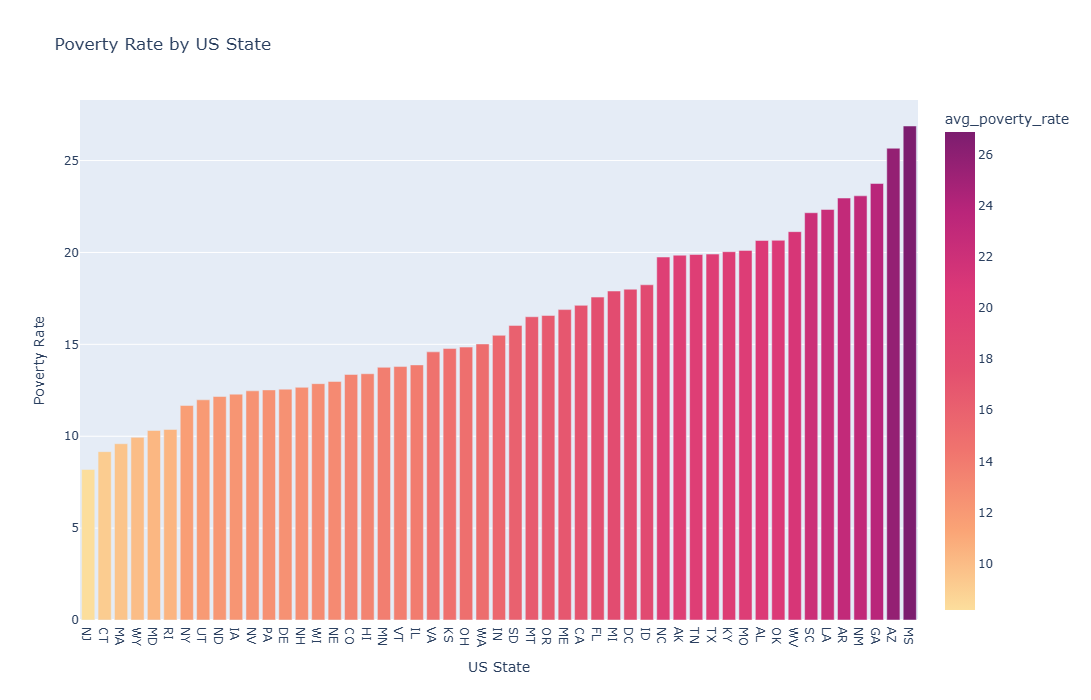

In [39]:
state_poverty_bar = px.bar(state_poverty, x='Geographic Area', y='avg_poverty_rate', color='avg_poverty_rate',
                           title='Poverty Rate by US State', color_continuous_scale='sunsetdark', height=700,
                            labels={'poverty_rate': 'Poverty Rate'})
state_poverty_bar.update_layout(xaxis_title='US State', yaxis_title='Poverty Rate')
state_poverty_bar.show()

# High School Graduation Rate by US State

In [40]:
# US state with lowest graduation rate
state, low_grad_rate = conn.execute("""
    SELECT "Geographic Area", ROUND(AVG(percent_completed_hs),2) as min_graduation_rate
    FROM income_hs_poverty
    GROUP BY "Geographic Area"
    ORDER BY min_graduation_rate
    LIMIT 1;""").fetchone()
print(f"The state with the lowest graduation rate is {state} at {low_grad_rate}%.")

The state with the lowest graduation rate is TX at 75.69%.


In [41]:
# US state with highest graduation rate
state, high_grad_rate = conn.execute("""
    SELECT "Geographic Area", ROUND(AVG(percent_completed_hs),2 ) as min_graduation_rate
    FROM income_hs_poverty
    GROUP BY "Geographic Area"
    ORDER BY min_graduation_rate DESC
    LIMIT 1;""").fetchone()
print(f"The state with the highest graduation rate is {state} at {high_grad_rate}%.")

The state with the highest graduation rate is MA at 92.4%.


In [42]:
# Query for graphing
hs_grad_rate = pd.read_sql_query("""
    SELECT "Geographic Area", ROUND(AVG(percent_completed_hs), 2) as graduation_rate
    FROM income_hs_poverty
    GROUP BY "Geographic Area"
    ORDER BY graduation_rate;""", conn)
hs_grad_rate.to_csv('data/csv_format/clean_data/hs_grad_rate.csv', index=False)

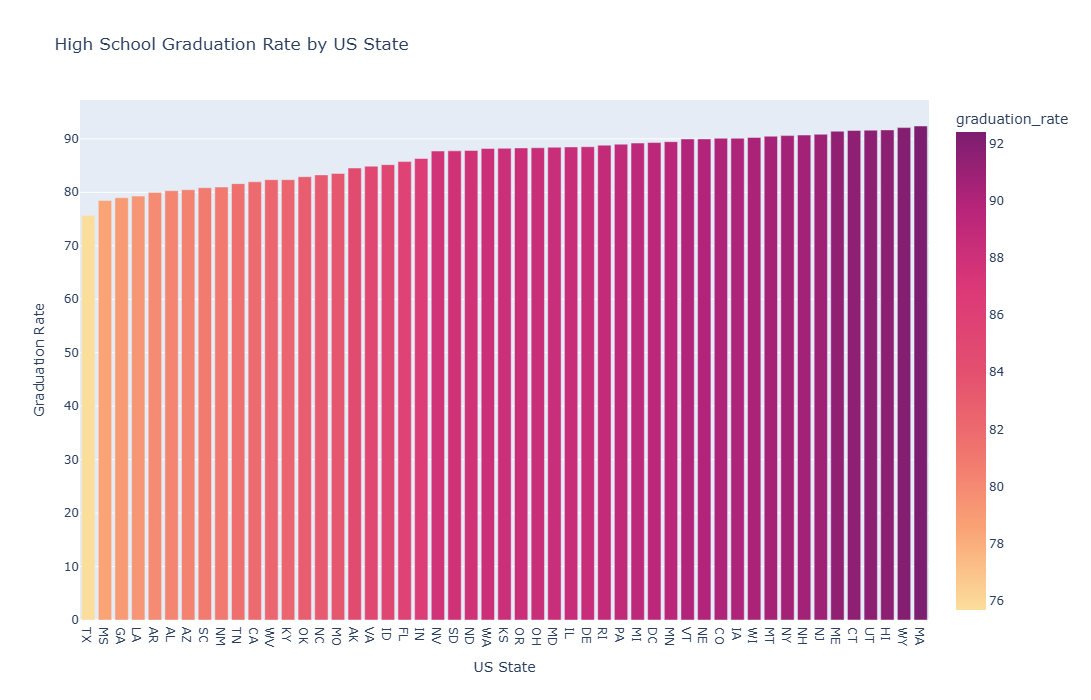

In [43]:
finish_hs_bar = px.bar(hs_grad_rate, x='Geographic Area', y='graduation_rate', color='graduation_rate',
                           title='High School Graduation Rate by US State', color_continuous_scale='sunsetdark', height=700)
finish_hs_bar.update_layout(xaxis_title='US State', yaxis_title="Graduation Rate")
finish_hs_bar.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Line chart with two y-axes to show if the ratios of poverty and high school graduation move together.  

In [44]:
poverty_hs = pd.read_sql_query("""
    SELECT "Geographic Area", ROUND(AVG(percent_completed_hs), 2) as hs_grad_rate, ROUND(AVG(poverty_rate), 2) as poverty_rate
    FROM income_hs_poverty
    GROUP BY "Geographic Area"
    ORDER BY poverty_rate DESC;
    """, conn)
poverty_hs.to_csv('data/csv_format/clean_data/poverty_hs.csv', index=False)

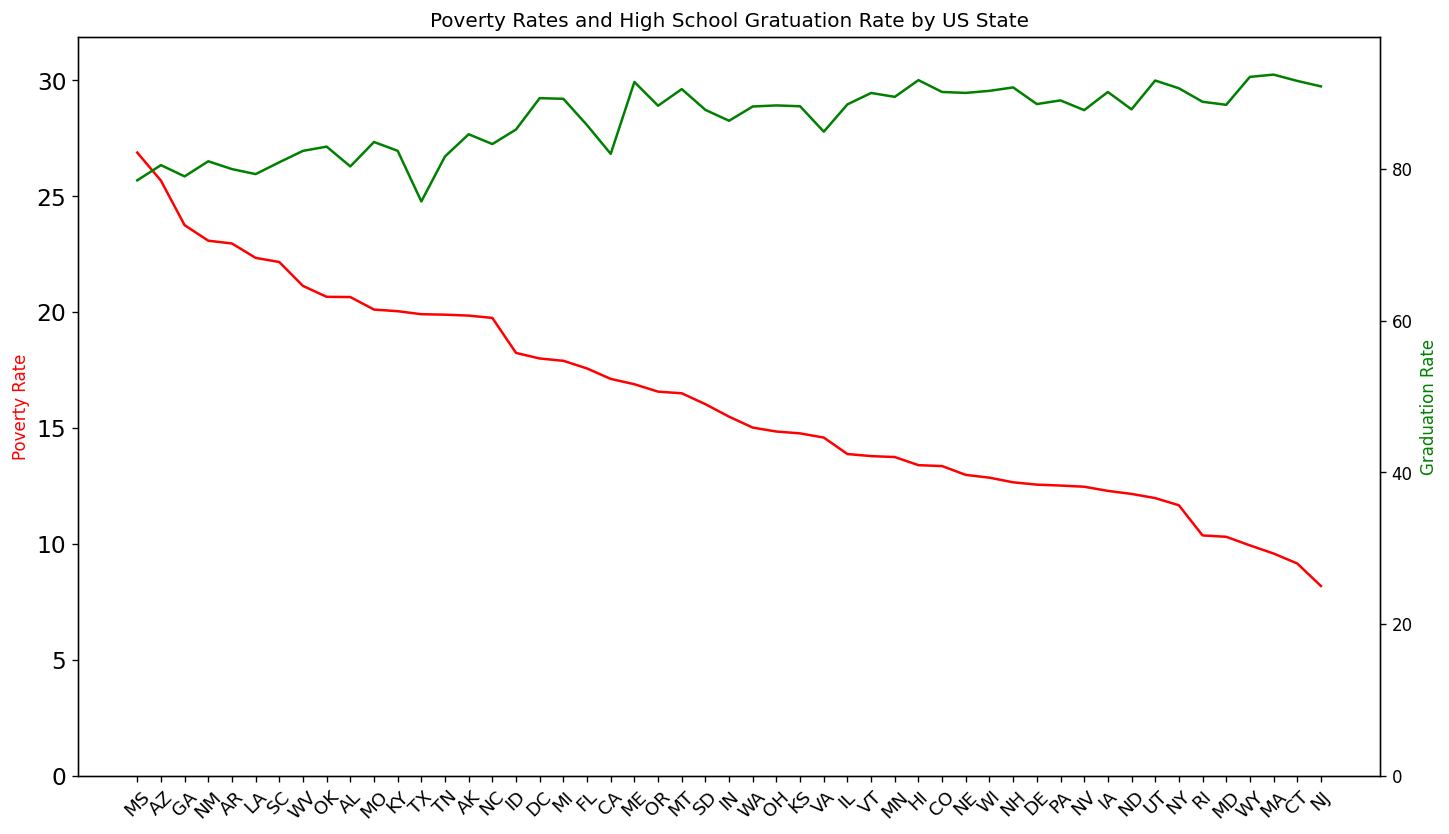

In [45]:
plt.figure(figsize=(14,8), dpi=120)
plt.xticks(fontsize=11, rotation=45)
plt.yticks(fontsize=14)
plt.title('Poverty Rates and High School Gratuation Rate by US State')

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylim([0, poverty_hs['poverty_rate'].max() + 5])
ax2.set_ylim([0, poverty_hs['hs_grad_rate'].max()+5])

ax1.plot(poverty_hs['Geographic Area'], poverty_hs['poverty_rate'], color="red")
ax2.plot(poverty_hs['Geographic Area'], poverty_hs['hs_grad_rate'], color='green')
ax1.set_ylabel("Poverty Rate", color='red')
ax2.set_ylabel("Graduation Rate", color='green')
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

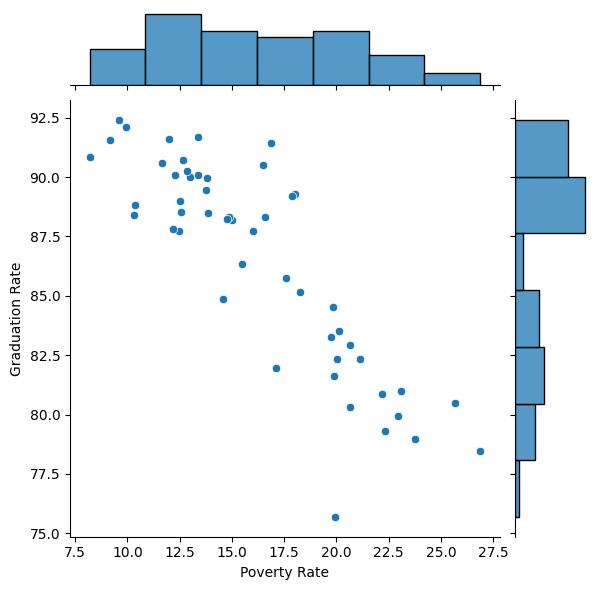

In [46]:
poverty_hs_kde = sns.jointplot(poverty_hs, kind='scatter', x='poverty_rate', y='hs_grad_rate')
poverty_hs_kde.set_axis_labels('Poverty Rate', 'Graduation Rate')
plt.show()

#### Seaborn's `.regplot()` to show any possible linear regression between the poverty ratio and the high school graduation ratio. 

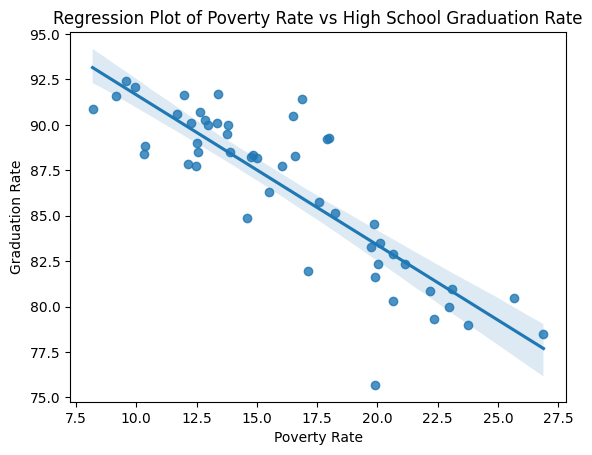

In [47]:
poverty_hs_reg = sns.regplot(poverty_hs, x='poverty_rate', y='hs_grad_rate')

poverty_hs_reg.set_xlabel('Poverty Rate')
poverty_hs_reg.set_ylabel('Graduation Rate')
poverty_hs_reg.set_title('Regression Plot of Poverty Rate vs High School Graduation Rate')

plt.show()

# Bar Chart with the Racial Makeup of Each US State

In [48]:
avg_race_city = pd.read_sql_query("""
    SELECT "Geographic Area", ROUND(AVG(share_white), 2) as White, ROUND(AVG(share_black), 2) as Black,
    ROUND(AVG(share_native_american), 2) as "Native American", ROUND(AVG(share_asian), 2) as Asian,
    ROUND(AVG(share_hispanic), 2) as Hispanic
    FROM race_by_city
    GROUP BY "Geographic Area"
    ORDER BY "Geographic Area";
    """, conn)
avg_race_city.to_csv('data/csv_format/clean_data/avg_race_city.csv', index=False)

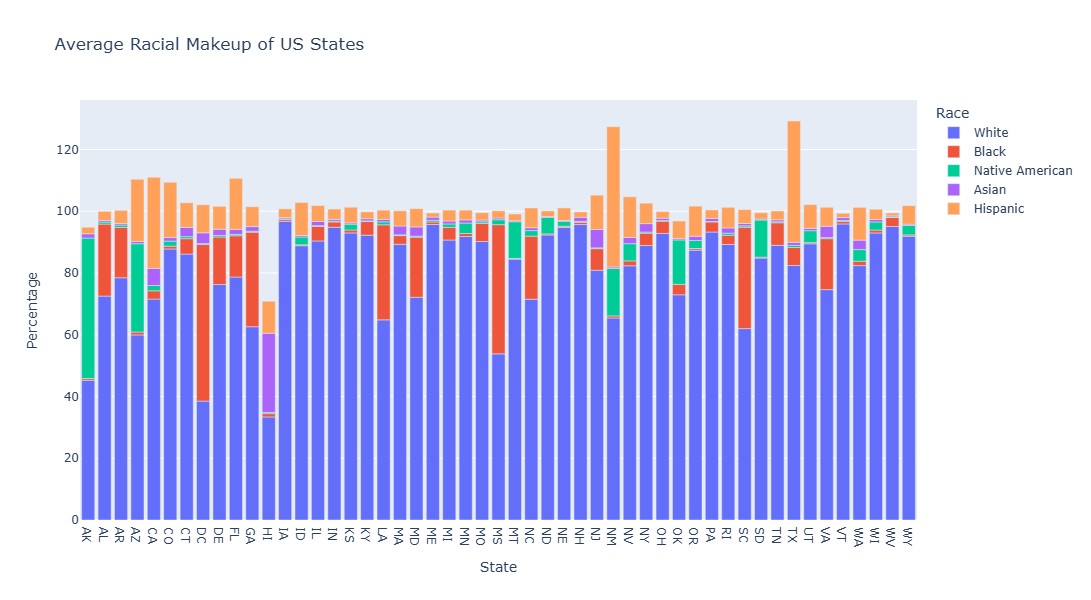

In [49]:
state_race_bar = px.bar(avg_race_city, x='Geographic area', y=['White', 'Black', 'Native American',
                                                    'Asian', 'Hispanic'],
                        title='Average Racial Makeup of US States', height=600)
state_race_bar.update_layout(xaxis_title='State', yaxis_title='Percentage', legend_title_text='Race')
state_race_bar.show()

In [50]:
# Use median
cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in cols:
    df_race_by_city[col] = pd.to_numeric(df_race_by_city[col], errors='coerce')

median_by_state = df_race_by_city.groupby('Geographic area')[cols].median().reset_index()
median_by_state = median_by_state.rename(columns={'share_white': 'White', 'share_black': 'Black', 'share_native_american': 'Native American',
                                                  'share_asian': 'Asian', 'share_hispanic': 'Hispanic'})

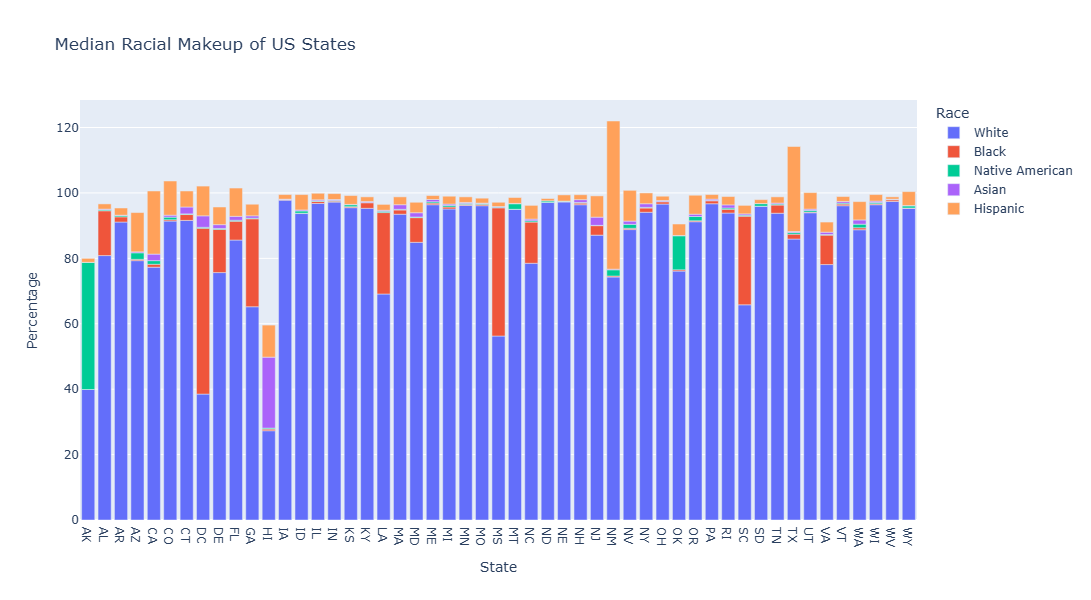

In [51]:
state_race_med = px.bar(median_by_state, x='Geographic area', y=['White', 'Black', 'Native American',
                                                    'Asian', 'Hispanic'],
                        title='Median Racial Makeup of US States', height=600)
state_race_med.update_layout(xaxis_title='State', yaxis_title='Percentage', legend_title_text='Race')
state_race_med.show()

### Will require total population data to calculate weighted averages for deeper analysis in the future

# Race of People Killed
### First total and then percentages

In [52]:
races_death_count = pd.read_sql_query("""
    SELECT race, COUNT(name) AS fatalities
    FROM fatalities
    GROUP BY race
    ORDER BY fatalities DESC;
    """, conn)
races_death_count

,race,fatalities
0,W,1201
1,B,618
2,H,423
3,unknown,195
4,A,39
5,N,31
6,O,28


In [53]:
# Dictionary to substitute words in for letters
race_map = {'W': 'White',
            'B': 'Black',
            'H': 'Hispanic',
            'A': 'Asian',
            'N': 'Native American',
            'O': 'Other',
           'unknown': 'Unknown'}

In [54]:
races_death_count['race'] = races_death_count['race'].map(race_map)
races_death_count.to_csv('data/csv_format/clean_data/race_death_count.csv', index=False)
races_death_count

,race,fatalities
0,White,1201
1,Black,618
2,Hispanic,423
3,Unknown,195
4,Asian,39
5,Native American,31
6,Other,28


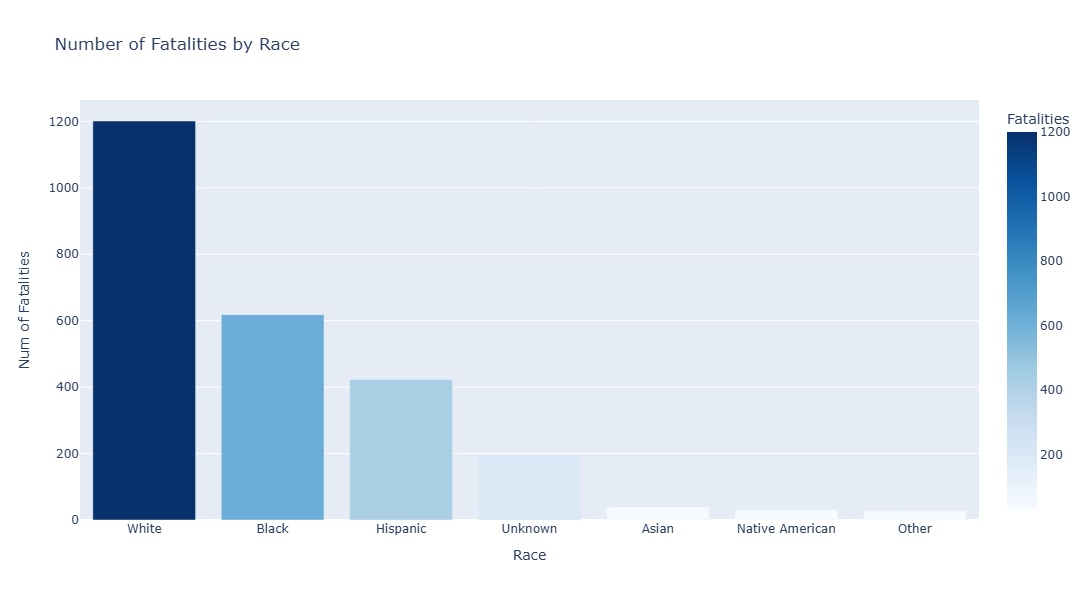

In [55]:
race_fata_bar = px.bar(races_death_count, x='race', y='fatalities', color='fatalities', title='Number of Fatalities by Race', height=600, 
                       color_continuous_scale='blues')
race_fata_bar.update_layout(xaxis_title='Race', yaxis_title='Num of Fatalities', coloraxis_colorbar_title='Fatalities')
race_fata_bar.show()

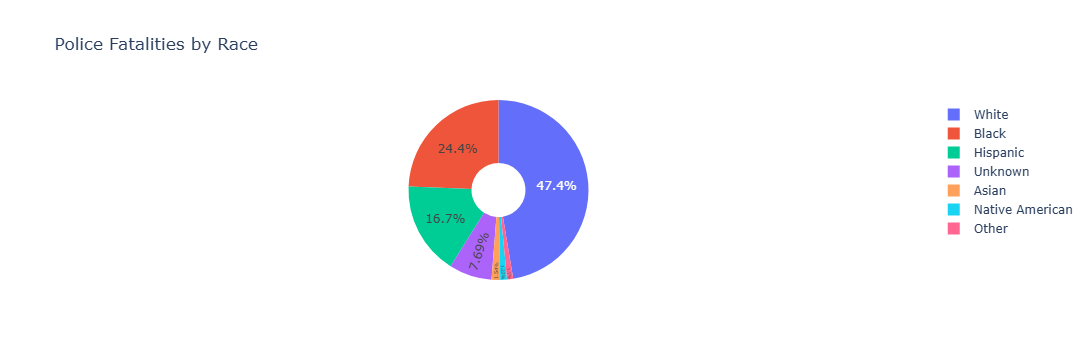

In [56]:
race_fatality_pie = px.pie(races_death_count, values='fatalities', title='Police Fatalities by Race', 
                           names='race', hole=0.3)
race_fatality_pie.update_traces(textposition='inside', textinfo='percent')
race_fatality_pie.show()

# Donut Chart Comparing the Total Deaths of Mean and Women 

In [57]:
gender_fatality = pd.read_sql_query("""
    SELECT gender, COUNT(gender) as fatalities
    FROM fatalities
    GROUP BY gender
    ORDER BY fatalities DESC;
    """, conn)
gender_fatality.to_csv('data/csv_format/clean_data/gender_fatality.csv', index=False)
gender_fatality

,gender,fatalities
0,M,2428
1,F,107


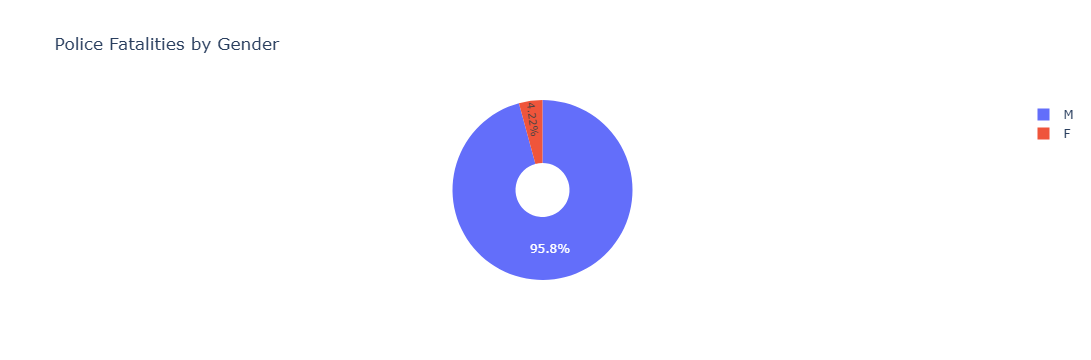

In [58]:
gender_fatality_pie = px.pie(gender_fatality, values='fatalities', title='Police Fatalities by Gender', 
                           names='gender', hole=0.3)
gender_fatality_pie.update_traces(textposition='inside', textinfo='percent')
gender_fatality_pie.show()

# Box Plots Showing the Age and Manner of Death

In [59]:
fatalities = pd.read_sql_query("""
    SELECT manner_of_death, age, gender
    FROM fatalities
    """, conn)
fatalities.to_csv('data/csv_format/clean_data/manner_of_death.csv', index=False)

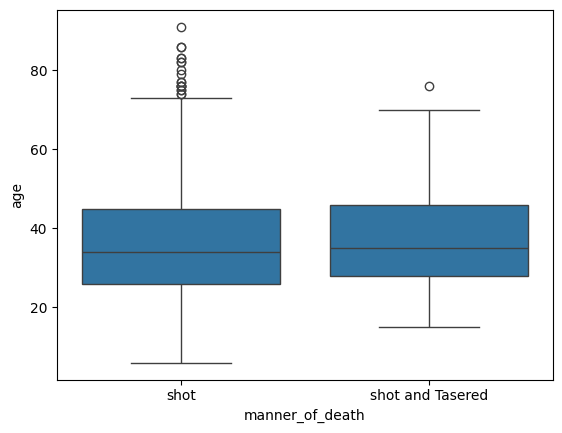

In [60]:
manner_of_death_box = sns.boxplot(data=fatalities, x='manner_of_death', y='age')
plt.show()

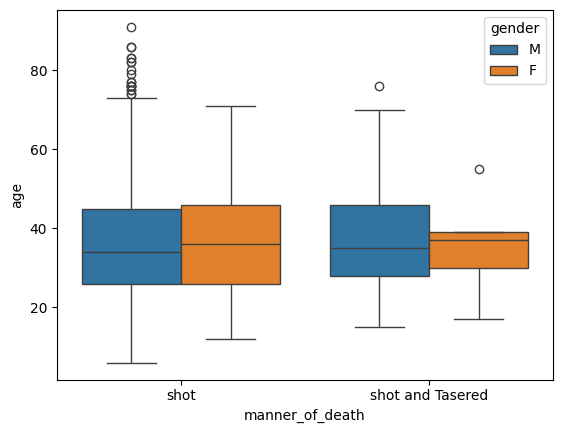

In [61]:
mod_gender = sns.boxplot(data=fatalities, x='manner_of_death', y='age', hue='gender')
plt.show()

# Were People Armed? 

In [62]:
armed_vs_unarmed = pd.read_sql_query("""
    SELECT armed, COUNT(*) AS fatalities
    FROM fatalities
    WHERE armed = "unarmed"
    UNION ALL
    SELECT armed, COUNT(*) AS fatalities
    FROM fatalities
    WHERE armed NOT IN ("unarmed", "undetermined", "missing", "undetermined")
    """, conn)

armed_vs_unarmed['armed'] = armed_vs_unarmed['armed'].replace('gun', 'armed')
armed_vs_unarmed.to_csv('data/csv_format/clean_data/armed_vs_unarmed.csv', index=False)
armed_vs_unarmed

,armed,fatalities
0,unarmed,171
1,armed,2238


Donut chart of unarmed vs armed

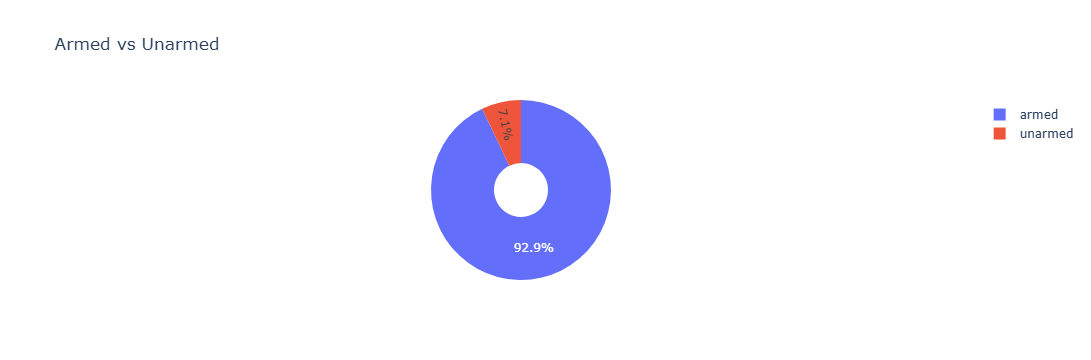

In [63]:
unarmed_armed_pie = px.pie(armed_vs_unarmed, values='fatalities', title='Armed vs Unarmed', 
                           names='armed', hole=0.3)
unarmed_armed_pie.update_traces(textposition='inside', textinfo='percent')
unarmed_armed_pie.show()

In [64]:
top_weapons = pd.read_sql_query("""
    SELECT armed, COUNT(armed) as total
    FROM fatalities
    WHERE armed NOT IN ("unarmed", "undetermined", "missing", "undetermined", "unknown weapon")
    GROUP BY armed
    ORDER BY total DESC
    LIMIT 20;
    """, conn)
top_weapons.to_csv('data/csv_format/clean_data/top_weapons.csv', index=False)
top_weapons

,armed,total
0,gun,1398
1,knife,373
2,vehicle,177
3,toy weapon,104
4,machete,18
5,ax,9
6,Taser,9
7,sword,8
8,baseball bat,8
9,metal pipe,7


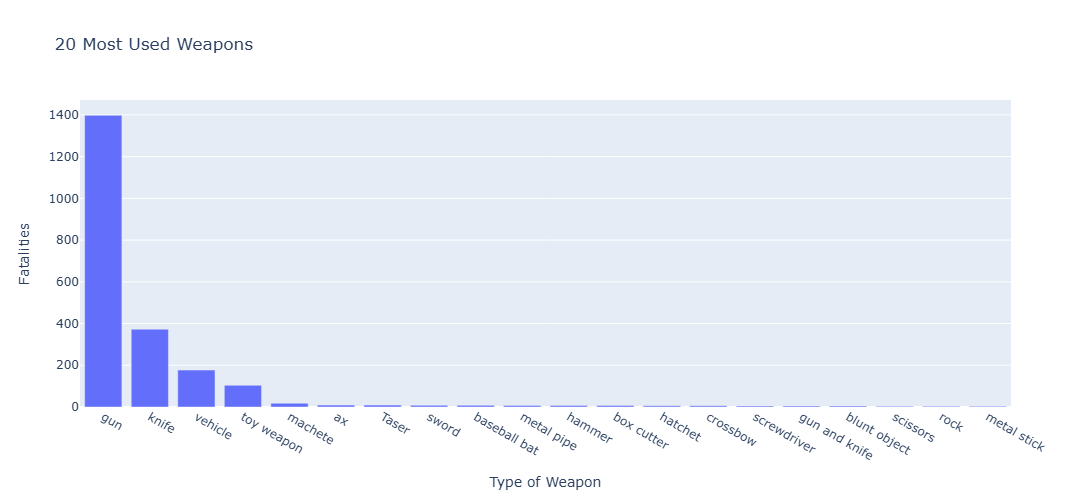

In [65]:
top_weapons_bar = px.bar(top_weapons, x='armed', y='total', height=500, title='20 Most Used Weapons')
top_weapons_bar.update_layout(xaxis_title='Type of Weapon', yaxis_title='Fatalities')
top_weapons_bar.show()

# How Old Were the People Killed?

Percentage of people killed who were under 25.

In [66]:
# Method 1
under_25 = df_fatalities[df_fatalities['age'] < 25]
under_25_pct = len(under_25) / len(df_fatalities) * 100
print(f'The percentage of people killed under 25 was {under_25_pct:.2f}%')

The percentage of people killed under 25 was 17.75%


In [67]:
# Method 2
result = cur.execute("""
    SELECT COUNT(CASE WHEN age < 25 THEN 1 END) * 100.0 / COUNT(*) AS under_25_pct
    FROM fatalities;""").fetchone()
print(f"The percentage of people killed under 25 was {result[0]:.2f}%.")

The percentage of people killed under 25 was 17.75%.


Histogram and KDE plot showing the distribution of ages of people killed by police. 

In [68]:
fatality_age = pd.read_sql_query("""
    SELECT age
    FROM fatalities;""", conn)
fatality_age.to_csv('data/csv_format/clean_data/fatalities_age.csv', index=False)

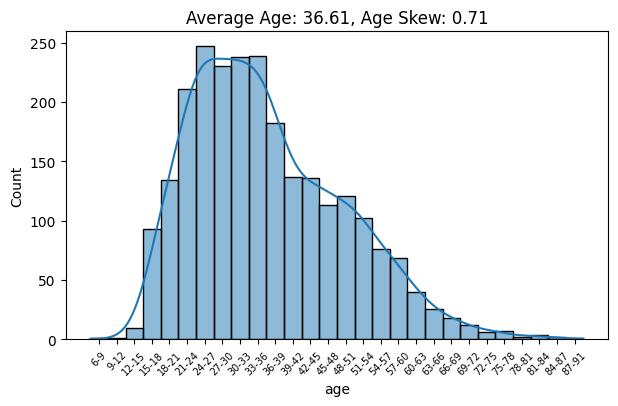

In [69]:
age_skew = round(fatality_age.age.skew(), 2)
avg_age_all = round(fatality_age.age.mean(), 2)
plt.figure(figsize=(7,4))
age_histo = sns.histplot(fatality_age, x='age', binwidth=3, kde=True)
plt.title(f'Average Age: {avg_age_all}, Age Skew: {age_skew}')
# Get bin labels
bins = [patch.get_x() for patch in age_histo.patches]
labels = [f"{int(patch.get_x())}-{int(patch.get_x() + patch.get_width())}" for patch in age_histo.patches]
plt.xticks(ticks=[b + 1.5 for b in bins], labels=labels, rotation=45, fontsize=7)
plt.show()

KDE plot for each race

In [70]:
race_age_fata = pd.read_sql_query("""
    SELECT age, race
    FROM fatalities;
    """, conn)

In [71]:
race_age_fata['race'] = race_age_fata['race'].map(race_map)
race_age_fata.to_csv('data/csv_format/clean_data/race_aga_fatalities.csv', index=False)

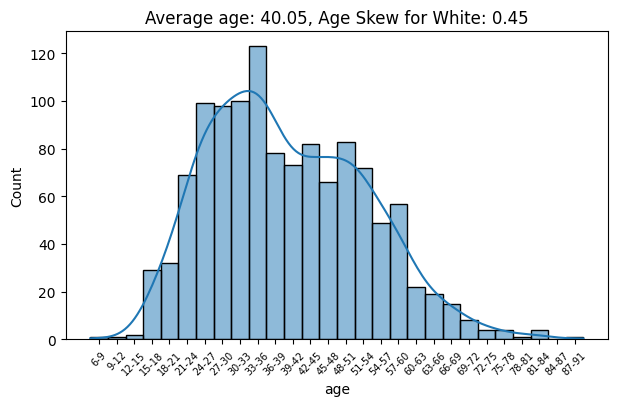

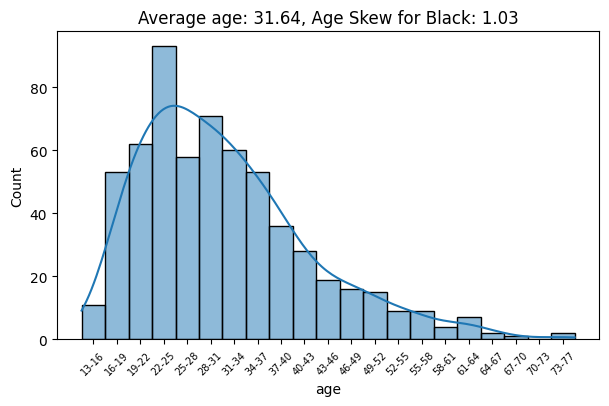

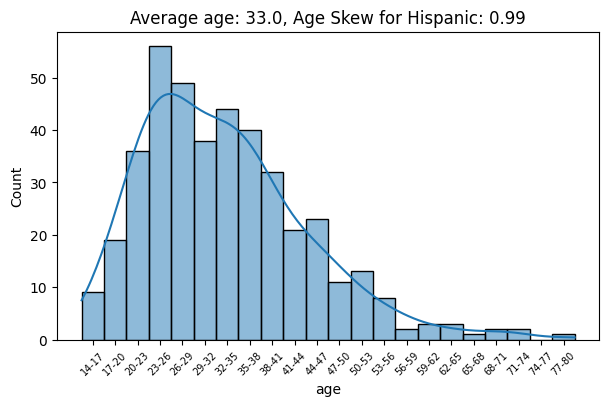

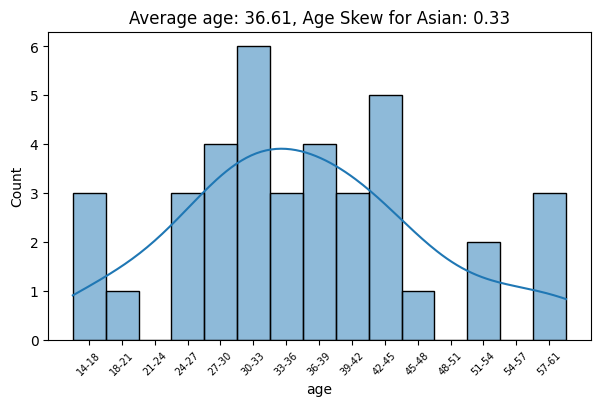

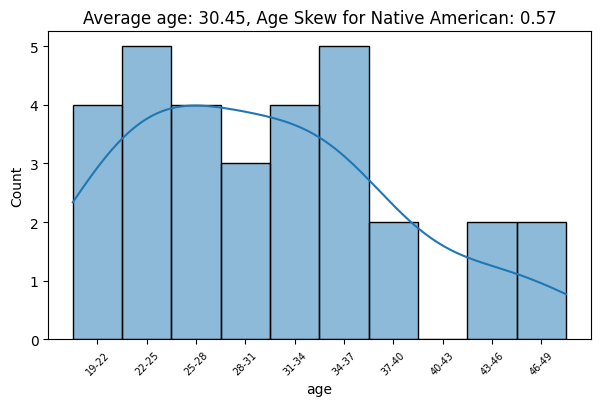

In [72]:
races = ['White', 'Black', 'Hispanic', 'Asian', 'Native American']
for r in races:
    target_race = race_age_fata[race_age_fata['race'] == r]
    race_age_skew = round(target_race.age.skew(), 2)
    avg_age = round(target_race['age'].mean(), 2)
    plt.figure(figsize=(7,4))
    histo = sns.histplot(target_race, x='age', binwidth=3, kde=True)
    plt.title(f'Average age: {avg_age}, Age Skew for {r}: {race_age_skew}')
    # Get bin labels
    bins = [patch.get_x() for patch in histo.patches]
    labels = [f"{int(patch.get_x())}-{int(patch.get_x() + patch.get_width())}" for patch in histo.patches]
    plt.xticks(ticks=[b + 1.5 for b in bins], labels=labels, rotation=45, fontsize=7)
    plt.show()

All of the graphs have a positive skew, with hispanics and blacks having the largest. This implies a larger concentration of
police related fatalities among younger ages in black and hispainc communities.

# Mental Illness and Police Related Fatalities

In [73]:
men_ill = pd.read_sql_query("""
    SELECT signs_of_mental_illness, COUNT(signs_of_mental_illness) AS count
    FROM fatalities
    GROUP BY signs_of_mental_illness;""", conn)
men_ill

,signs_of_mental_illness,count
0,0,1902
1,1,633


In [74]:
men_ill = men_ill.replace(to_replace=[0, 1], value=[False, True])
men_ill.to_csv('data/csv_format/clean_data/sings_men_ill.csv', index=False)
men_ill

,signs_of_mental_illness,count
0,False,1902
1,True,633


In [75]:
mi_yes = men_ill.loc[men_ill['signs_of_mental_illness'] == True, 'count'].iloc[0]
mi_pct = (mi_yes / len(df_fatalities)) * 100
print(f'The percentage of people killed by police who have been diagnosed with signs of a mental illness is {mi_pct:.2f}%')

The percentage of people killed by police who have been diagnosed with signs of a mental illness is 24.97%


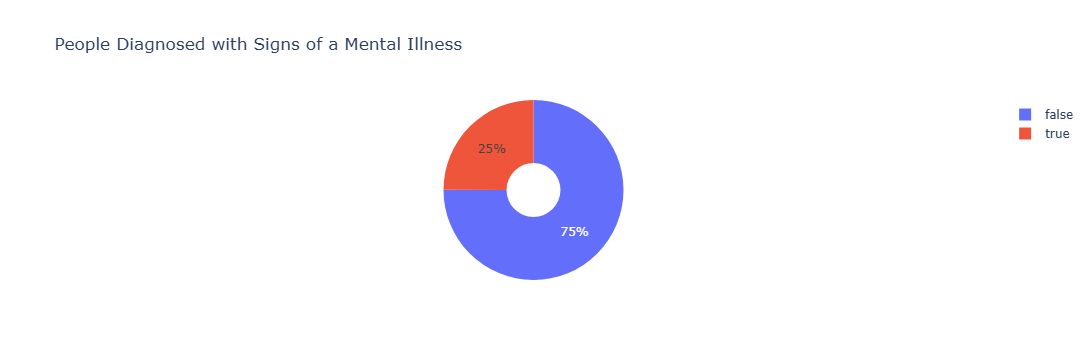

In [76]:
mi_pie = px.pie(men_ill, values='count', title='People Diagnosed with Signs of a Mental Illness', names='signs_of_mental_illness',
                hole=0.3)
mi_pie.update_traces(textposition='inside', textinfo='percent')
mi_pie.show()

# In Which Cities Do the Most Police Killings Take Place?

In [77]:
city_fata = pd.read_sql_query("""
    SELECT state, city, COUNT(name) as fatalities_count
    FROM fatalities
    GROUP BY state, city
    ORDER BY fatalities_count DESC
    LIMIT 10;""", conn)
city_fata.to_csv('data/csv_format/clean_data/fatal_cities.csv', index=False)
city_fata

,state,city,fatalities_count
0,CA,Los Angeles,39
1,AZ,Phoenix,31
2,TX,Houston,26
3,IL,Chicago,25
4,NV,Las Vegas,21
5,TX,San Antonio,20
6,FL,Miami,17
7,OH,Columbus,17
8,TX,Austin,16
9,MO,St. Louis,15


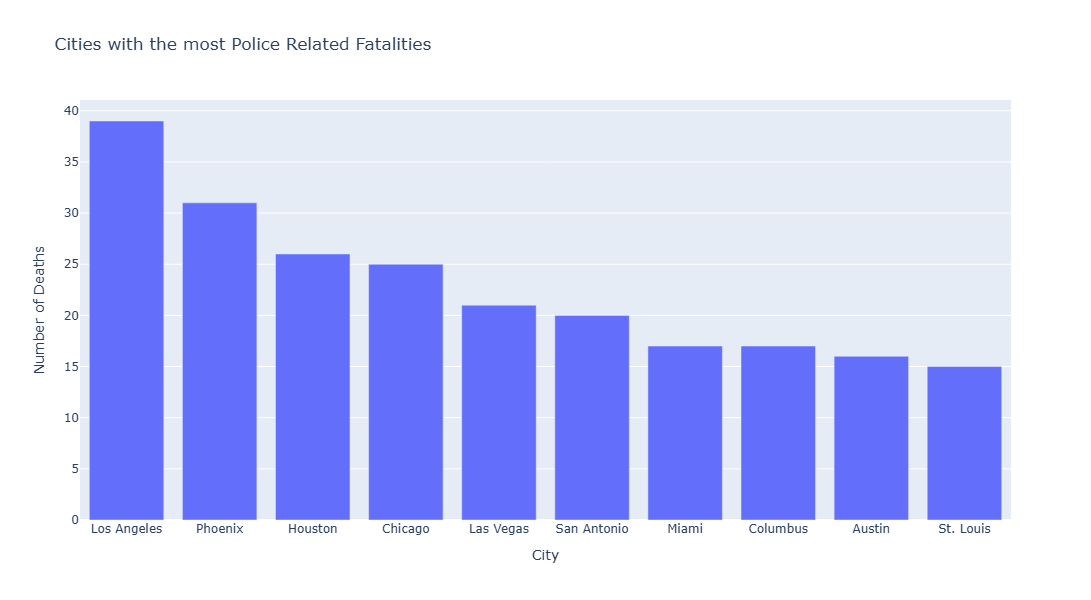

In [78]:
fatality_city_bar = px.bar(city_fata, x='city', y='fatalities_count', title='Cities with the most Police Related Fatalities',
                           height=600)
fatality_city_bar.update_layout(xaxis_title='City', yaxis_title='Number of Deaths')
fatality_city_bar.show()

# Rate of Death by Race in Top 10 Cities

In [79]:
# Find the number of each race killed in the top 10 cities
fata_race_city = pd.read_sql_query("""
    SELECT state, city, race, COUNT(*) as total_fatalities
    FROM Fatalities
    WHERE race IN ("B", "W", "H", "A", "N") AND 
        ((state = "CA" AND city = "Los Angeles") OR
        (state = "AZ" AND city = "Phoenix") OR
        (state = "TX" AND city = "Houston") OR
        (state = "IL" AND city = "Chicago") OR
        (state = "NV" AND city = "Las Vegas") OR
        (state = "FL" AND city = "Miami") OR
        (state = "OH" AND city = "Columbus") OR 
        (state = "TX" AND city = "Austin") OR 
        (state = "MO" AND city = "St. Louis") OR
        (state = "TX" AND city = "San Antonio"))
    GROUP BY state, city, race
    ORDER BY city, total_fatalities DESC ;""", conn)
fata_race_city['race'] = fata_race_city['race'].map(race_map)
print(fata_race_city.shape)
fata_race_city.to_csv('data/csv_format/clean_data/fatality_race_city.csv', index=False)
fata_race_city.head()

(31, 4)


,state,city,race,total_fatalities
0,TX,Austin,White,11
1,TX,Austin,Black,3
2,TX,Austin,Hispanic,2
3,IL,Chicago,Black,21
4,IL,Chicago,White,2


In [80]:
race_color_map = {
    'White': '#636EFA',  # blue
    'Black': '#EF553B',  # red
    'Asian': '#00CC96',  # green
    'Hispanic': '#AB63FA',  # purple
    'Native American': '#FFA15A',   # orange
}

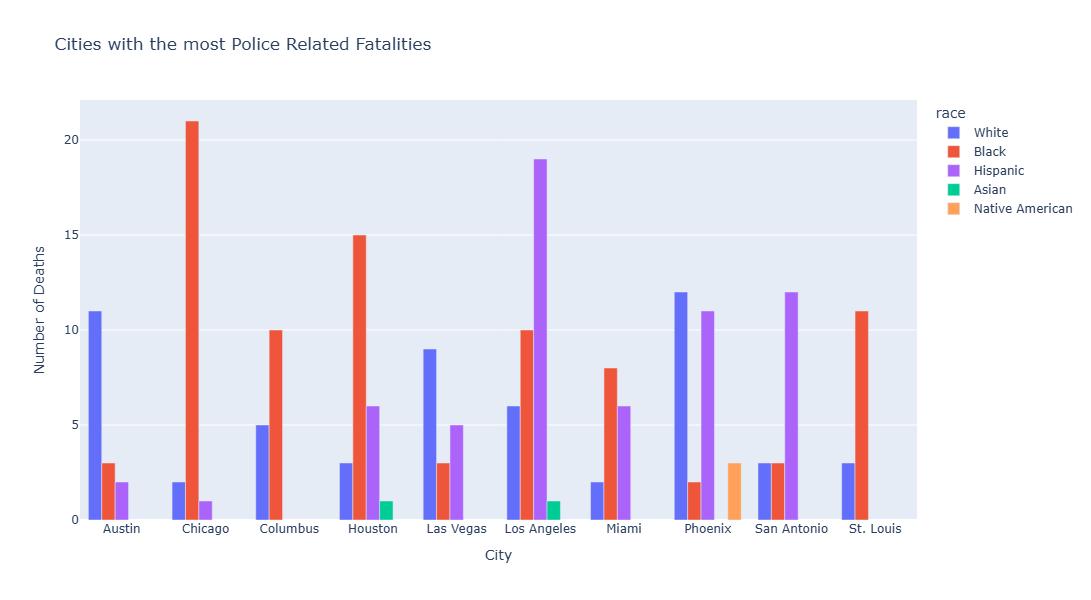

In [81]:
fata_race_city_bar = px.bar(fata_race_city, x='city', y='total_fatalities', title='Cities with the most Police Related Fatalities',
                           height=600, barmode='group', color='race', color_discrete_map=race_color_map)
fata_race_city_bar.update_layout(xaxis_title='City', yaxis_title='Number of Deaths')
fata_race_city_bar.show()

In [82]:
# Find percentage of that race

In [83]:
cities = fata_race_city['city'].unique()

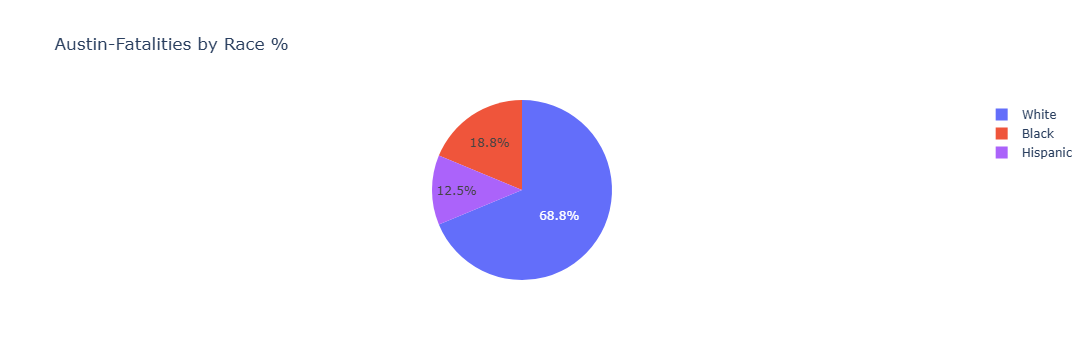

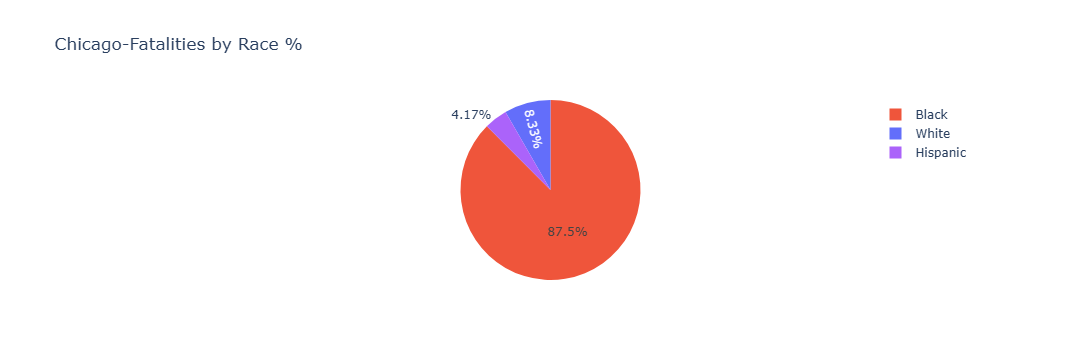

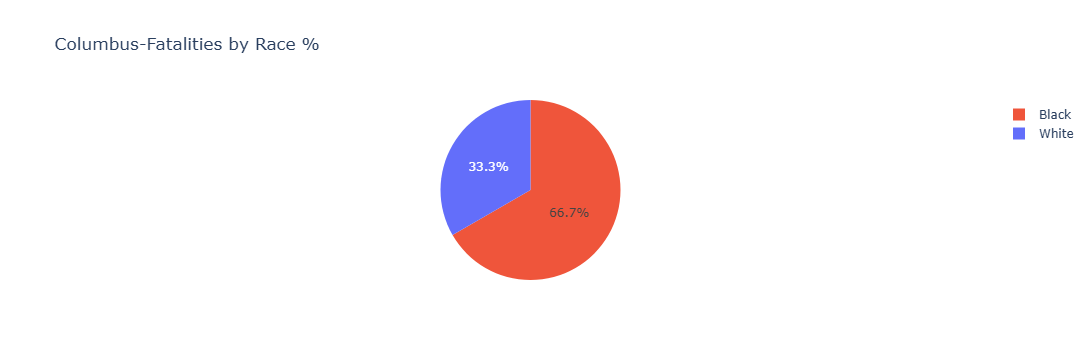

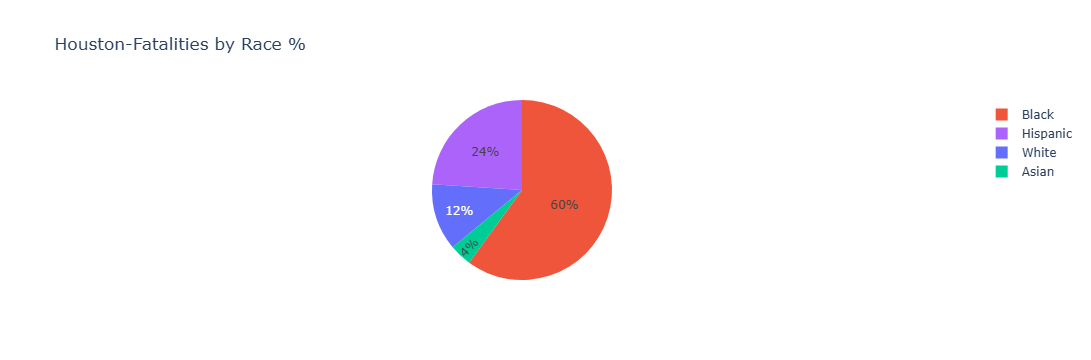

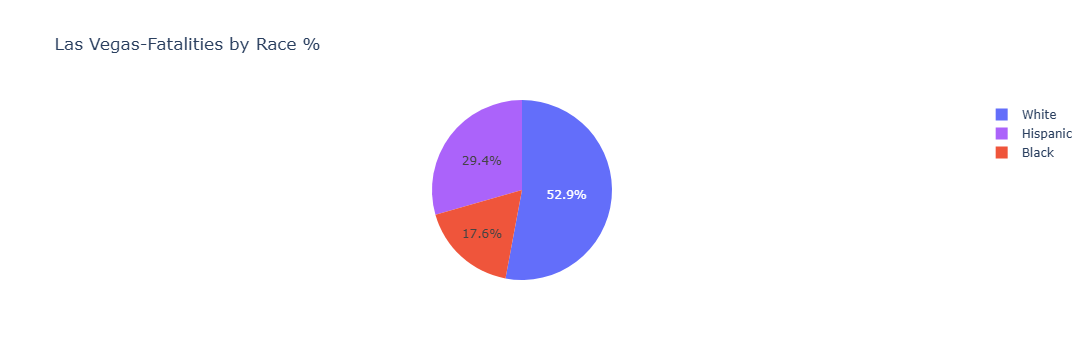

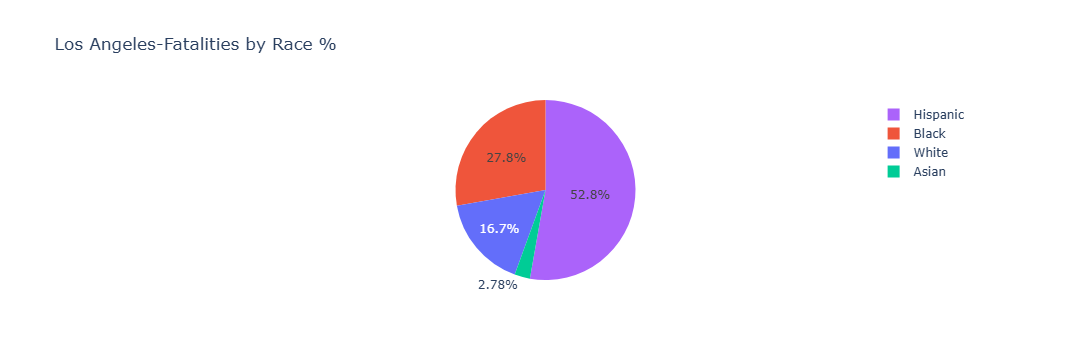

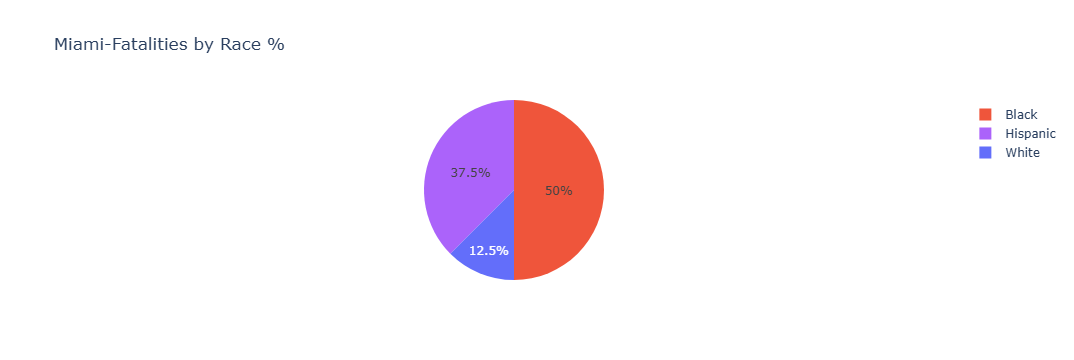

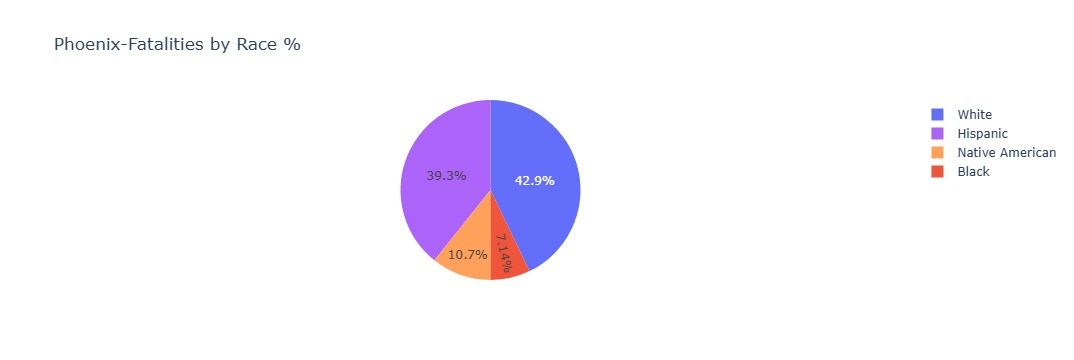

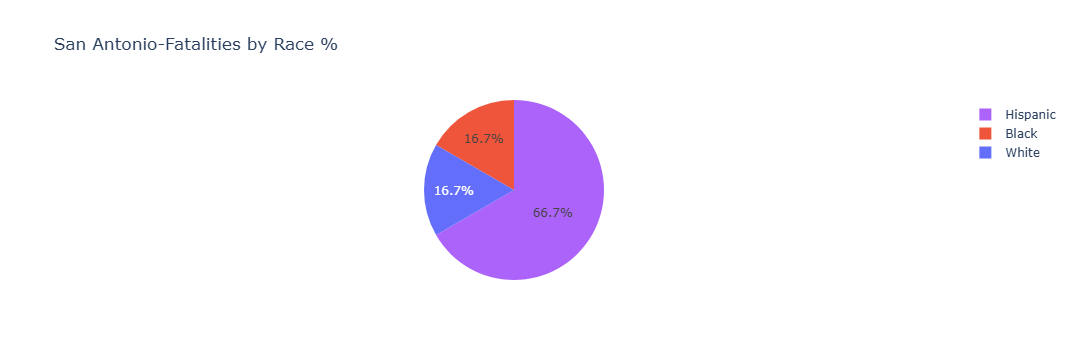

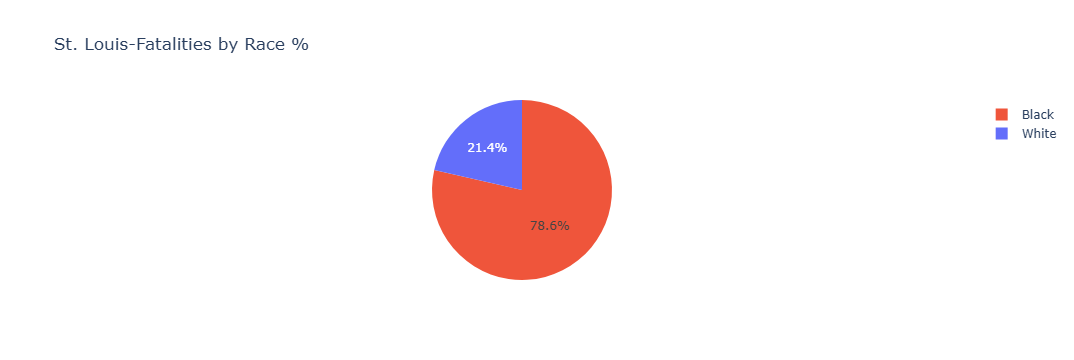

In [84]:
for city in cities:
    city_makeup = fata_race_city[fata_race_city['city'] == city]
    race_city_pie = px.pie(city_makeup, names='race', values='total_fatalities', color='race', title=f"{city}-Fatalities by Race %", 
                           color_discrete_map=race_color_map)
    race_city_pie.show()

# Choropleth Map of Police Killings by US State

In [85]:
query = """
WITH fatality_counts AS (
    SELECT state, COUNT(*) AS total_fatalities
    FROM fatalities
    GROUP BY state),
    
    poverty_avg AS (
    SELECT "Geographic Area" as state, ROUND(AVG(poverty_rate), 2) as avg_poverty_rate
    FROM income_hs_poverty
    GROUP BY state)
    
    SELECT f.state, f.total_fatalities, p.avg_poverty_rate
    FROM fatality_counts f
    LEFT JOIN poverty_avg p ON p.state = f.state
    ORDER BY f.total_fatalities DESC;"""

state_pov_fata = pd.read_sql_query(query, conn)
state_pov_fata.to_csv('data/csv_format/clean_data/state_pov_fatalities.csv', index=False)
state_pov_fata.head()

,state,total_fatalities,avg_poverty_rate
0,CA,424,17.12
1,TX,225,19.91
2,FL,154,17.57
3,AZ,118,25.67
4,OH,79,14.85


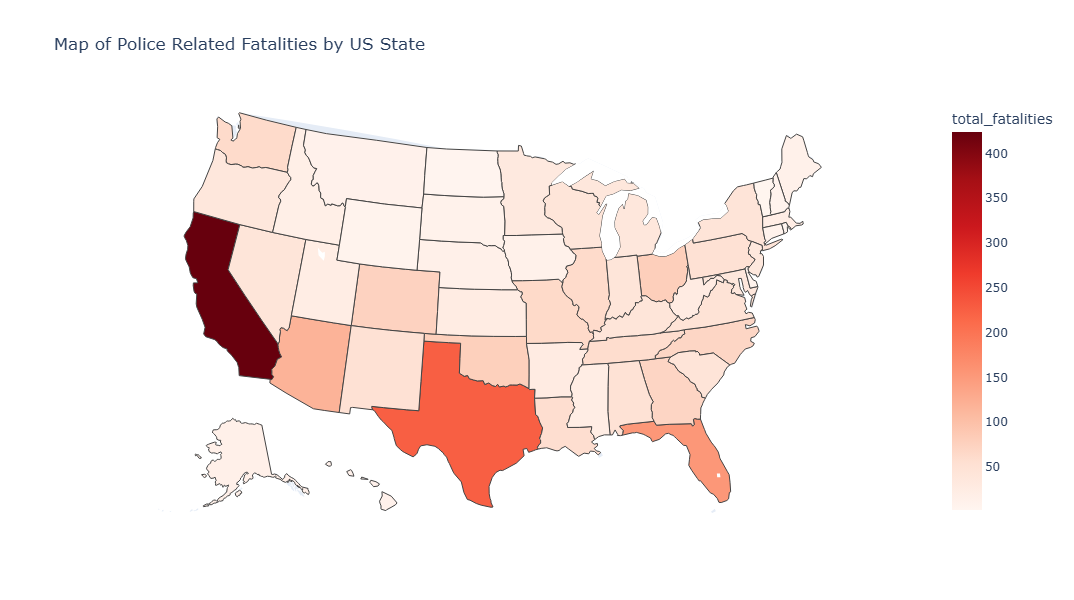

In [86]:
state_killings_map = px.choropleth(state_pov_fata, locations='state', locationmode='USA-states', 
                                   color='total_fatalities', color_continuous_scale='reds', height=600, 
                                   title='Map of Police Related Fatalities by US State')
state_killings_map.update_layout(geo_scope='usa')
state_killings_map.show()

### Is there any type of relationship between poverty rate and fatalities in the data?

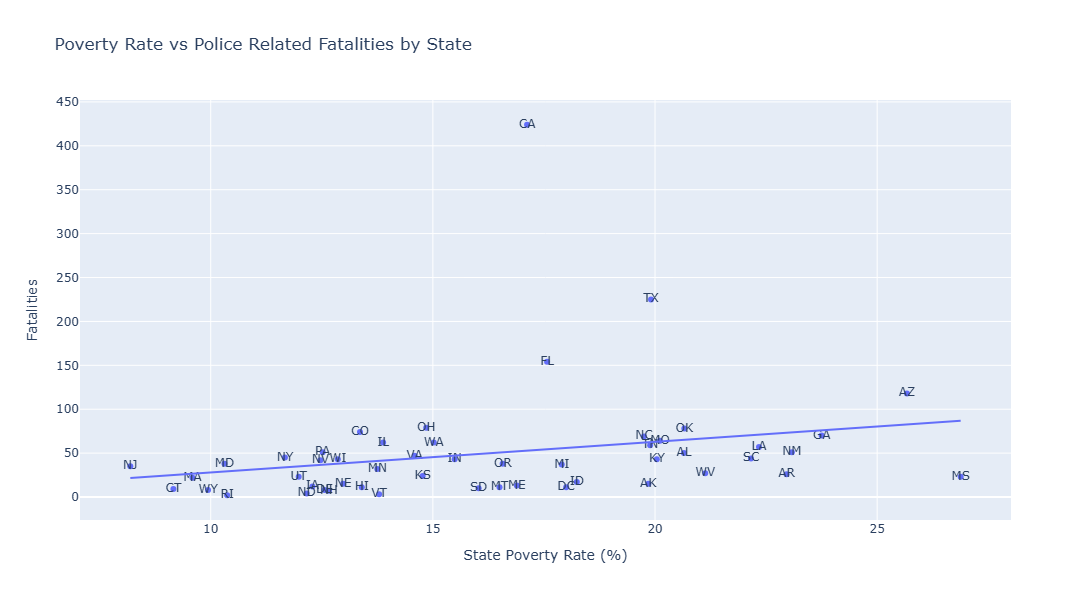

In [87]:
pov_vs_fata = px.scatter(state_pov_fata, x='avg_poverty_rate', y='total_fatalities', text='state',
                         trendline='ols', title='Poverty Rate vs Police Related Fatalities by State', height=600)
pov_vs_fata.update_layout(xaxis_title='State Poverty Rate (%)', yaxis_title='Fatalities')
pov_vs_fata.show()

# Number of Police Killings Over Time

In [88]:
# Convert date column to datetime format
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], format='%d/%m/%y')
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-01-02,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [89]:
# Count killings per month
monthly_killings = df_fatalities.groupby(by=df_fatalities.date.dt.strftime('%Y-%m')).agg(
    {'name': 'count'}).rename(columns={'name': 'Killings'}).reset_index()
monthly_killings.to_csv('data/csv_format/clean_data/montly_killings.csv', index=False)
monthly_killings.head()

,date,Killings
0,2015-01,76
1,2015-02,77
2,2015-03,92
3,2015-04,84
4,2015-05,71


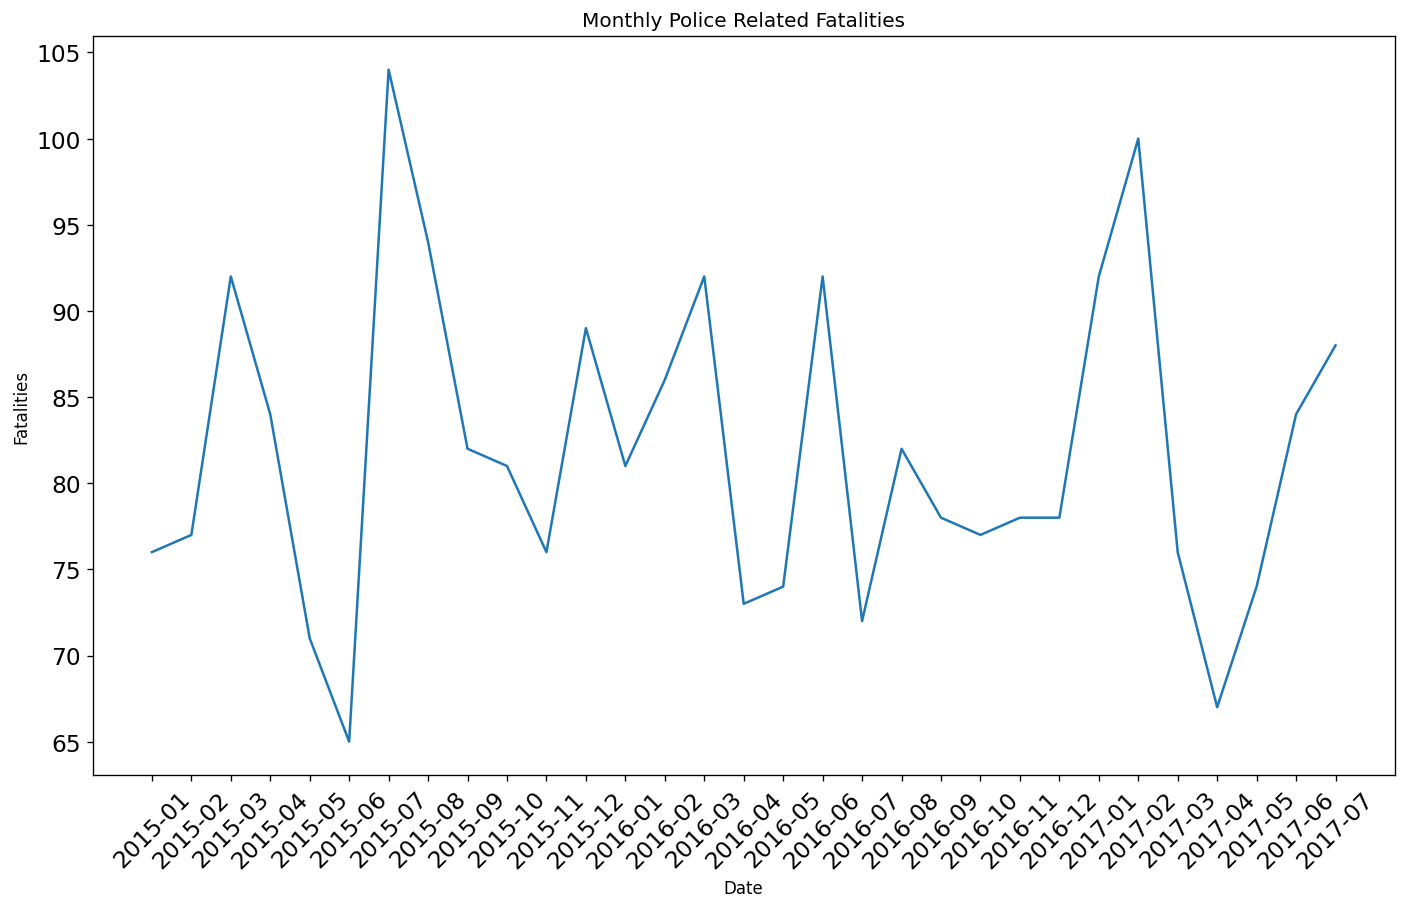

In [90]:
# Plot killings over the 2 year time span
plt.figure(figsize=(14,8), dpi=120)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)

ax = plt.gca()

plt.plot(monthly_killings['date'], monthly_killings['Killings'])
plt.title("Monthly Police Related Fatalities")
ax.set_xlabel('Date')
ax.set_ylabel('Fatalities')
plt.show()

In [91]:
# Not much trend monthly, so let's compare yearly
yearly_killings = df_fatalities.groupby(by=df_fatalities.date.dt.year).agg(
    {'name': 'count'}).reset_index()
yearly_killings = yearly_killings.rename(columns={'date': 'Year', 'name': 'Killings'})
yearly_killings.to_csv('data/csv_format/clean_data/yearly_killings.csv', index=False)
yearly_killings.head()

,Year,Killings
0,2015,991
1,2016,963
2,2017,581


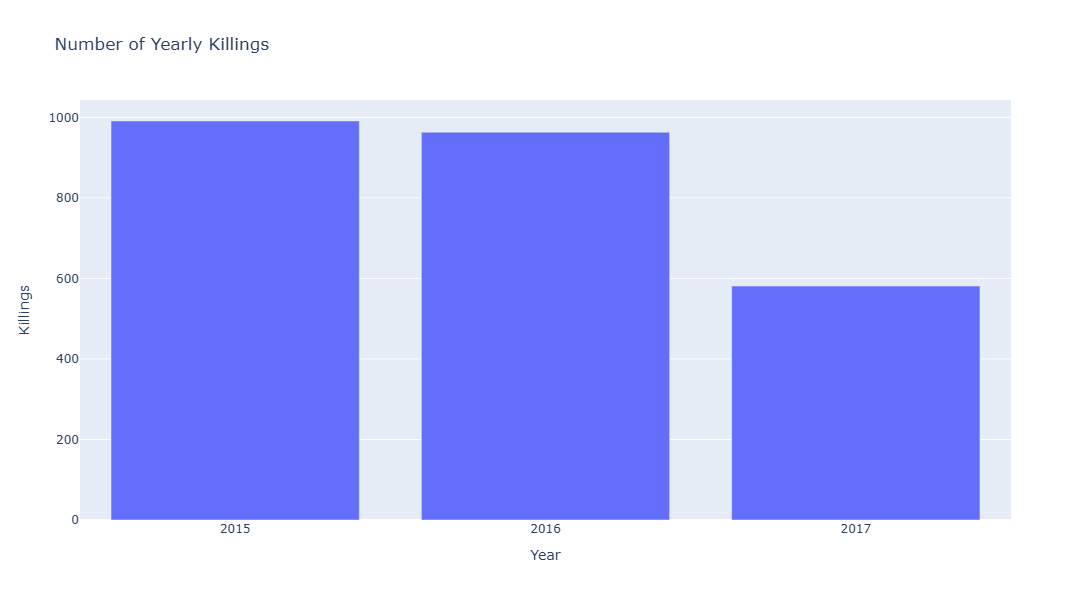

In [92]:
yearly_killings_bar = px.bar(yearly_killings, x=['2015', '2016', '2017'], y='Killings', height=600, title='Number of Yearly Killings')
yearly_killings_bar.update_layout(xaxis_title='Year')
yearly_killings_bar.show()

In [93]:
conn.close()